In [53]:
# Notebook bootstrap: make project imports work from any launch directory.
from pathlib import Path
import os
import sys

try:
    ip = get_ipython()  # type: ignore[name-defined]
    if ip is not None:
        ip.run_line_magic('load_ext', 'autoreload')
        ip.run_line_magic('autoreload', '2')
except Exception:
    pass

cwd = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'main.py').exists() and (candidate / 'config').is_dir():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root (expected main.py and config/).')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print(f'Using repo root: {REPO_ROOT}')

import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import traceback

from training import *
from utils import *
from analysis.common_fourier import *
from analysis.common_trig import *
from config import Config
from analysis.analysis_utils import *
from utils import (
    get_device,
    create_dataset,
    create_model,
    print_dataset_info,
    evaluate_model,
    filter_data_by_operation,
    load_model,
    plot_training_curves,
    resolve_checkpoint,
    extract_checkpoint_accuracies,
)
from analysis.rnn import ablation as rnn_ablation
from analysis.rnn import combined_ablation as rnn_combined_ablation
from analysis.rnn import fourier as rnn_fourier
from analysis.rnn import svd as rnn_svd
from analysis.rnn import trig as rnn_trig
from analysis.transformer import ablation as transformer_ablation
from analysis.transformer import combined_ablation as transformer_combined_ablation
from analysis.transformer import fourier as transformer_fourier
from analysis.transformer import svd as transformer_svd
from analysis.transformer import trig as transformer_trig

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using repo root: /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/cramming


## Experiment Selection Options

Use the picker cell below to choose a run from `paper_rerun_models`.

### Supported choices
- `TASK_TYPE`: `single-op` or `multi-op`
- `NTERMS`: `2`, `3`, or `4` (depending on availability)
- `REGIME`:
  - `cot` = scratchpad supervision (`training_target: seq_cot`)
  - `mask` / `e2e-mask` = end-to-end style folders
- `OPS_SLUG`:
  - single-op examples: `add`, `sub`, `mult`, `div`
  - multi-op examples: `add_sub`, `add_mult`, `add_div`, `div_mult`, `div_sub`, `mult_sub`

### Fallback behavior
- If picker path is missing, set `EXPERIMENT_REL_PATH_OVERRIDE` directly.
- Checkpoint loading prefers `checkpoints/best.pt`, then `checkpoints/final.pt`.


In [ ]:
# Reproducible experiment picker
import os
from pathlib import Path
import torch

# --- Picker knobs ---
TASK_TYPE = 'multi-op'   # 'single-op' or 'multi-op'
NTERMS = 3               # 2, 3, 4
REGIME = 'cot'           # e.g. 'cot', 'mask', 'e2e-mask'
OPS_SLUG = 'add_sub'     # e.g. add, sub, mult, div, add_sub, ...

# Optional explicit override (recommended when exploring custom runs):
# EXPERIMENT_REL_PATH_OVERRIDE = 'paper_rerun_models/multi-op/3_term/cot/add_sub'
EXPERIMENT_REL_PATH_OVERRIDE = None

CHECKPOINT_NAME = 'checkpoints/best.pt'
DEVICE = None  # None, 'cpu', or 'cuda'

base = Path('paper_rerun_models') / TASK_TYPE / f'{NTERMS}_term' / REGIME / OPS_SLUG
if EXPERIMENT_REL_PATH_OVERRIDE:
    exp_path = Path(EXPERIMENT_REL_PATH_OVERRIDE)
else:
    exp_path = base

if not exp_path.is_absolute():
    exp_path = (Path(REPO_ROOT) / exp_path).resolve()

# Helpful listing for users
candidate_cfgs = sorted((Path(REPO_ROOT) / 'paper_rerun_models').glob('**/config.yaml'))
print(f'paper_rerun_models configs found: {len(candidate_cfgs)}')
for c in candidate_cfgs[:15]:
    print(' -', c.parent.relative_to(REPO_ROOT))
if len(candidate_cfgs) > 15:
    print(f' ... ({len(candidate_cfgs)-15} more)')

if not exp_path.exists():
    raise FileNotFoundError(
        f'Experiment directory not found: {exp_path}\n'
        f'Picker selection was: TASK_TYPE={TASK_TYPE}, NTERMS={NTERMS}, REGIME={REGIME}, OPS_SLUG={OPS_SLUG}'
    )

EXPERIMENT_PATH = str(exp_path)
config_path = os.path.join(EXPERIMENT_PATH, 'config.yaml')
if not os.path.exists(config_path):
    raise FileNotFoundError(f'No config file found at {config_path}')

preferred_model_path = os.path.join(EXPERIMENT_PATH, CHECKPOINT_NAME)
final_model_path = os.path.join(EXPERIMENT_PATH, 'checkpoints/final.pt')
if os.path.exists(preferred_model_path):
    model_path = preferred_model_path
elif os.path.exists(final_model_path):
    model_path = final_model_path
else:
    model_path = preferred_model_path

print(f'Analyzing experiment at: {EXPERIMENT_PATH}')
print(f'Config path: {config_path}')
print(f'Checkpoint path: {model_path}')

if os.path.exists(model_path):
    ckpt_meta = torch.load(model_path, map_location='cpu')
    ckpt_epoch = ckpt_meta.get('epoch') if isinstance(ckpt_meta, dict) else None
    print(f"Checkpoint epoch: {ckpt_epoch if ckpt_epoch is not None else 'N/A'}")
else:
    print('Checkpoint epoch: N/A (no best/final checkpoint found yet)')


In [55]:
# Load Configuration
if os.path.exists(config_path):
    print(f"Loading configuration from {config_path}")
    config = Config.load(config_path)
    # Ensure config knows where to save outputs (figures)
    config.training.save_dir = EXPERIMENT_PATH 
else:
    raise FileNotFoundError(f"No config file found at {config_path}")

device = get_device(DEVICE)
print(f"Using device: {device}")

if config.model_type == 'transformer':
    print("Model Type: Transformer")
else:
    print("Model Type: RNN")

print("Operations:", config.operations)

# Show configured training epoch count
epoch_count = getattr(getattr(config, "training", None), "epochs", None)
if epoch_count is not None:
    print(f"Epochs: {epoch_count}")
else:
    print("Epochs: not set in config.training")

# Create Dataset
dataset = create_dataset(config.operations, config.data.to_dict(), device)
print(f"Dataset created with size: {len(dataset)}")
print(f"Operations: {config.operations}")


Loading configuration from /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/cramming/paper_rerun_models/multi-op/3_term/cot/add_sub/config.yaml
Using device: mps
Model Type: Transformer
Operations: ['addition', 'subtraction']
Epochs: 5000
Dataset created with size: 137842
Operations: ['addition', 'subtraction']


In [56]:
print('\n=== Fourier Spectrum Analysis Report ===\n')

# Notebook mode: view plots inline only (disable file writes)
SAVE_FIGURES = False
if not SAVE_FIGURES:
    try:
        ip = get_ipython()  # type: ignore[name-defined]
        if ip is not None:
            ip.run_line_magic('matplotlib', 'inline')
    except Exception:
        pass

    from IPython.display import display

    def _display_instead_of_savefig(*args, **kwargs):
        # analysis helpers call savefig() then close(); display before close.
        display(plt.gcf())

    plt.savefig = _display_instead_of_savefig
    print('Figure saving disabled; figures will display inline.')

analysis_path = EXPERIMENT_PATH
ckpt_path = model_path if os.path.exists(model_path) else resolve_checkpoint(analysis_path)
model, checkpoint = load_model(ckpt_path, config.model.to_dict(), device=str(device))
dataset = dataset.to_device(str(device))
analysis_cache = {}

if config.model_type == 'transformer':
    fourier_analysis = transformer_fourier
    svd_analysis = transformer_svd
    ablation_analysis = transformer_ablation
    combined_ablation_analysis = transformer_combined_ablation
    trig_analysis = transformer_trig
else:
    fourier_analysis = rnn_fourier
    svd_analysis = rnn_svd
    ablation_analysis = rnn_ablation
    combined_ablation_analysis = rnn_combined_ablation
    trig_analysis = rnn_trig

train_acc, test_acc, epoch = extract_checkpoint_accuracies(checkpoint)

print(f"Epoch: {epoch if epoch is not None else 'N/A'}")
print('1. Model performance:')
train_acc_str = f'{train_acc}%' if train_acc is not None else 'N/A'
test_acc_str  = f'{test_acc}%'  if test_acc  is not None else 'N/A'
print(
    f'Accuracy on entire dataset: {evaluate_model(model, dataset.dataset, dataset.labels)}%'
    f' \n\t Train set accuracy: {train_acc_str}'
    f' \n\t Test set accuracy: {test_acc_str}'
)
print('Per-operation accuracy:')
for op in config.operations:
    op_all_data, op_all_labels = filter_data_by_operation(dataset, op, split='all', target='final')
    op_train_data, op_train_labels = filter_data_by_operation(dataset, op, split='train', target='final')
    op_test_data, op_test_labels = filter_data_by_operation(dataset, op, split='test', target='final')

    op_all_acc = evaluate_model(model, op_all_data, op_all_labels)
    op_train_acc = evaluate_model(model, op_train_data, op_train_labels)
    op_test_acc = evaluate_model(model, op_test_data, op_test_labels)

    print(
        f' \n\t {op.capitalize()} - total: {op_all_acc}%'
        f' \n\t {op.capitalize()} - train: {op_train_acc}%'
        f' \n\t {op.capitalize()} - test: {op_test_acc}%'
    )



=== Fourier Spectrum Analysis Report ===

Figure saving disabled; figures will display inline.
Epoch: 4934
1. Model performance:
Accuracy on entire dataset: 100.0% 
	 Train set accuracy: 100.0% 
	 Test set accuracy: 100.0%
Per-operation accuracy:
 
	 Addition - total: 100.0% 
	 Addition - train: 100.0% 
	 Addition - test: 100.0%
 
	 Subtraction - total: 100.0% 
	 Subtraction - train: 100.0% 
	 Subtraction - test: 100.0%



=== ADDITION ===
2. Generating fourier coefficient analysis plots
Skipping hidden-state Fourier coefficient heatmaps: nterms=3 (only implemented for nterms=2 pairwise grids).


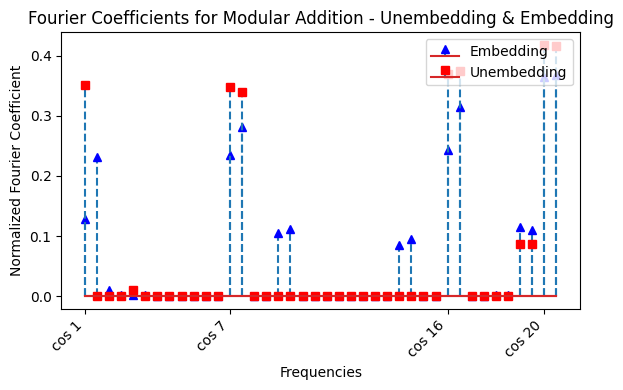

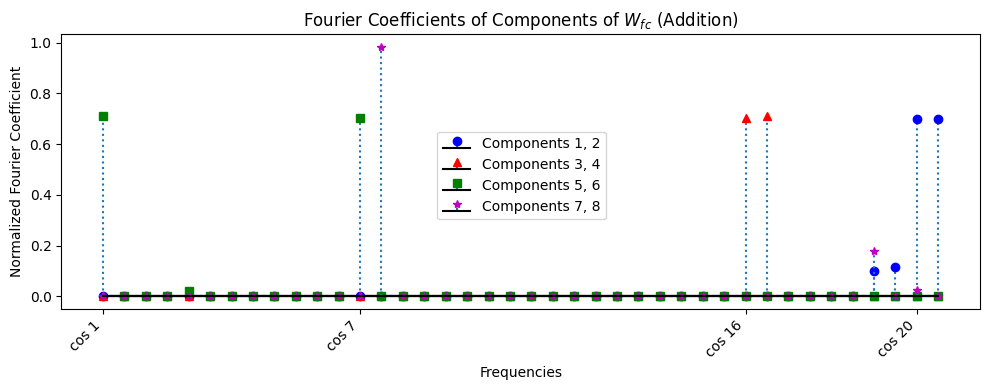


5. Trigonometric Identity Verification:
Skipping transformer addition trig identity verification for nterms=3. This check is currently defined for nterms=2.


=== SUBTRACTION ===
2. Generating fourier coefficient analysis plots
Skipping hidden-state Fourier coefficient heatmaps: nterms=3 (only implemented for nterms=2 pairwise grids).


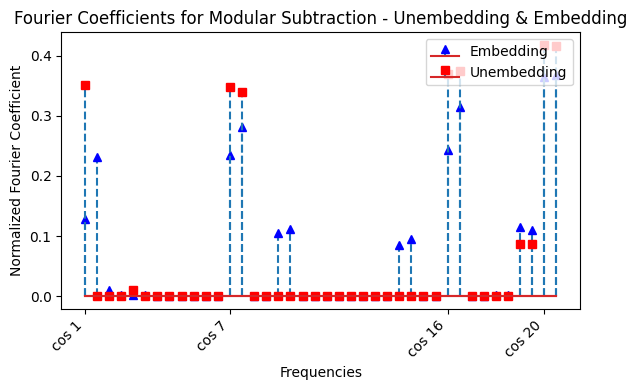

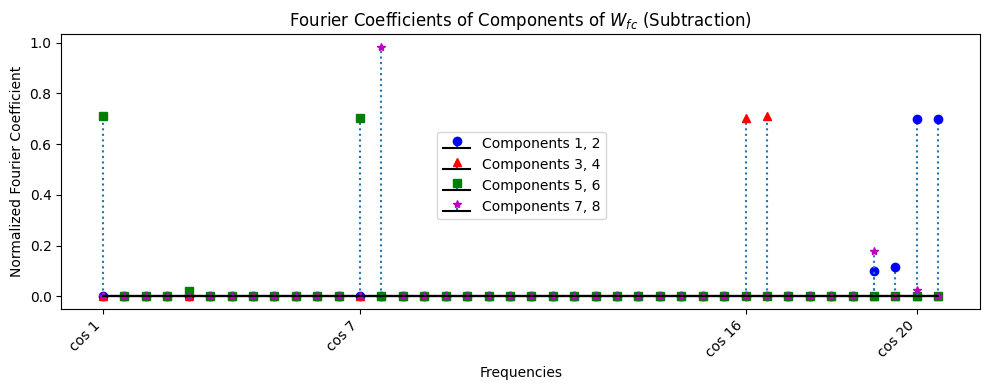


5. Trigonometric Identity Verification:
Skipping transformer subtraction trig identity verification for nterms=3. This check is currently defined for nterms=2.


6. Generating Weight SVD spectrum plots (whole model)
Fraction of Variance in significant components for Addition + Subtraction:
Embedding Weights, 8 components: 0.7168
Unembedding Weights, 8 components: 0.9673


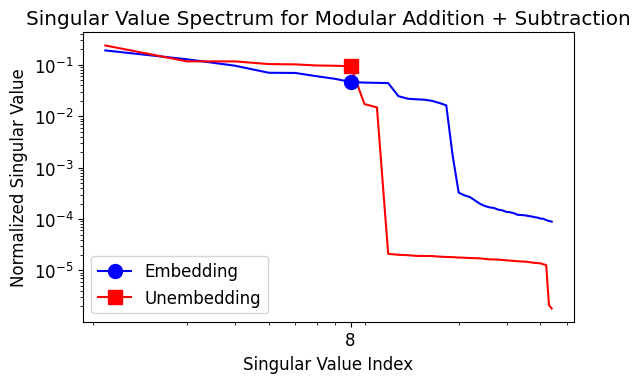


7. Performing combined-ip-elbow embedding/unembedding ablation analysis
Combined-ip-elbow ablation (Transformer): keeping top 8 components in embedding/unembedding
  -> Accuracy on addition: 4.44%
  -> Accuracy on subtraction: 3.67%

8. Plotting per-operation accuracy vs kept top-k singular components
Combined-ip-elbow accuracy sweep (transformer): evaluating k=0..13 (embedding/unembedding top-k components kept)


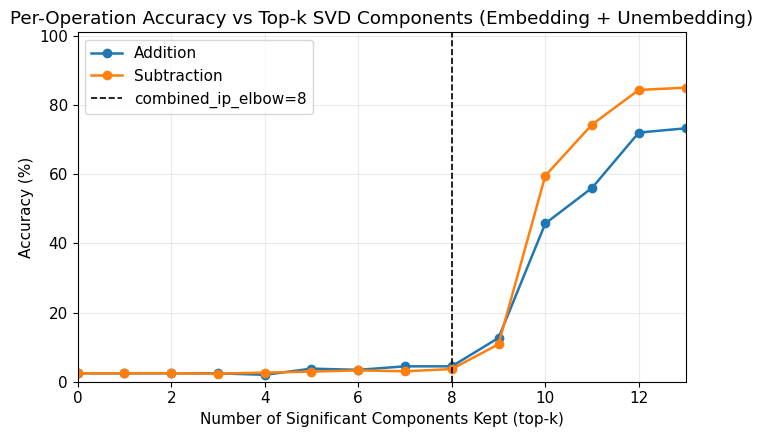

Saved combined-ip accuracy curve: /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/cramming/paper_rerun_models/multi-op/3_term/cot/add_sub/figures/combined_ip_svd_accuracy_curve.png

=== Analysis Complete ===


In [57]:

op_elbows = {}
for op in config.operations:
    op_elbows[op] = fourier_analysis.compute_ip_elbow(
        checkpoint, dataset, op,
        norm_threshold=config.analysis.fourier_norm_threshold,
        fourier_reg_mode=config.training.fourier_reg_mode,
        analysis_cache=analysis_cache,
    )

for op in config.operations:
    ip_elbow = op_elbows[op]
    print(f'\n=== {op.upper()} ===')

    print('2. Generating fourier coefficient analysis plots')
    fourier_analysis.fourier_spectrum_analysis_plotting(
        model, checkpoint, dataset, analysis_path, op,
        fourier_reg_mode=config.training.fourier_reg_mode,
        norm_threshold=config.analysis.fourier_norm_threshold,
        freq_threshold_top_fraction=config.analysis.freq_threshold_top_fraction,
        freq_threshold_min_components=config.analysis.freq_threshold_min_components,
        freq_threshold_fixed=config.analysis.freq_threshold_fixed,
        analysis_cache=analysis_cache,
    )
    print()

    print('3. Performing SVD ablation analysis')
    try:
        ablation_analysis.svd_ablation_analysis(
            config.model.to_dict(), checkpoint, dataset, op, ip_elbow,
            fourier_reg_mode=config.training.fourier_reg_mode,
            analysis_cache=analysis_cache,
        )
    except Exception as e:
        print(f'Exception: {e}')
    print()

    print('4. Performing fourier component ablation analysis')
    try:
        ablation_analysis.fourier_ablation_analysis(
            config.model.to_dict(), checkpoint, dataset, op, ip_elbow,
            fourier_reg_mode=config.training.fourier_reg_mode,
            analysis_cache=analysis_cache,
        )
    except Exception as e:
        print(f'Exception: {e}')
    print()

    if op in ('addition', 'subtraction'):
        print('5. Trigonometric Identity Verification:')
        try:
            if op == 'addition':
                trig_analysis.verify_trigonometric_identity(
                    model,
                    checkpoint,
                    dataset,
                    freq_threshold_top_fraction=config.analysis.freq_threshold_top_fraction,
                    freq_threshold_min_components=config.analysis.freq_threshold_min_components,
                    freq_threshold_fixed=config.analysis.freq_threshold_fixed,
                    analysis_cache=analysis_cache,
                )
            else:
                trig_analysis.verify_trigonometric_identity_subtraction(
                    model,
                    checkpoint,
                    dataset,
                    freq_threshold_top_fraction=config.analysis.freq_threshold_top_fraction,
                    freq_threshold_min_components=config.analysis.freq_threshold_min_components,
                    freq_threshold_fixed=config.analysis.freq_threshold_fixed,
                    analysis_cache=analysis_cache,
                )
        except Exception as e:
            print(f'Exception: {e}')
        print()

print('\n6. Generating Weight SVD spectrum plots (whole model)')
try:
    svd_analysis.svd_spectrum_analysis_plotting_model(
        model,
        checkpoint,
        dataset,
        analysis_path,
        op_elbows,
        config.operations,
        analysis_cache=analysis_cache,
    )
except Exception as e:
    print(f'Exception: {e}')
print()

print('7. Performing combined-ip-elbow embedding/unembedding ablation analysis')
try:
    combined_ablation_analysis.combined_ip_svd_ablation_analysis(
        config.model.to_dict(),
        checkpoint,
        dataset,
        op_elbows,
        config.operations,
        analysis_cache=analysis_cache,
    )
except Exception as e:
    print(f'Exception: {e}')
print()

print('8. Plotting per-operation accuracy vs kept top-k singular components')
try:
    combined_ablation_analysis.combined_ip_svd_ablation_accuracy_curve(
        config.model.to_dict(),
        checkpoint,
        dataset,
        analysis_path,
        op_elbows,
        config.operations,
        analysis_cache=analysis_cache,
    )
except Exception as e:
    print(f'Exception: {e}')
print()

print('=== Analysis Complete ===')

In [58]:
def _operation_mask(data_tensor, dataset, operation):
    equals_token = dataset.modulo if dataset.includes_zero else dataset.modulo - 1
    target_op_token = equals_token + 1 + dataset.operations.index(operation)
    op_positions = list(range(1, data_tensor.shape[1] - 1, 2))

    if getattr(dataset, 'mixed_ops_within_sequence', False):
        mask = torch.zeros(data_tensor.size(0), dtype=torch.bool, device=data_tensor.device)
        for pos in op_positions:
            mask |= (data_tensor[:, pos] == target_op_token)
        return mask

    mask = torch.ones(data_tensor.size(0), dtype=torch.bool, device=data_tensor.device)
    for pos in op_positions:
        mask &= (data_tensor[:, pos] == target_op_token)
    return mask


def get_operation_tokens_and_labels(dataset, operation, nterms=None):
    if bool(getattr(dataset, 'is_variable_length', False)):
        if nterms is None:
            raise ValueError('nterms must be provided for variable-length datasets')
        shard = dataset.by_nterms[int(nterms)]
        tokens = shard['dataset']
        labels = shard['labels']
        mask = _operation_mask(tokens, dataset, operation)
        return tokens[mask], labels[mask]

    return dataset.get_full_data(operation)


def _apply_positional_encoding(model, x, device):
    if getattr(model, 'use_rope', False):
        return x
    if getattr(model, 'pos_enc', None) is not None:
        return model.pos_enc(x)
    if getattr(model, 'pos_embedding', None) is not None:
        pos = torch.arange(x.size(1), device=device).unsqueeze(0)
        return x + model.pos_embedding(pos)
    return x


def _run_standard_encoder_layer(layer, x, attn_mask):
    mha = layer.self_attn

    if layer.norm_first:
        sa_in = layer.norm1(x)
        sa_out_raw, attn_ref = mha(
            sa_in, sa_in, sa_in,
            attn_mask=attn_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        sa_out = layer.dropout1(sa_out_raw)
        after_sa_block = x + sa_out
        ffd_out = layer._ff_block(layer.norm2(after_sa_block))
        after_ffd = after_sa_block + ffd_out
    else:
        sa_in = x
        sa_out_raw, attn_ref = mha(
            sa_in, sa_in, sa_in,
            attn_mask=attn_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        sa_out = layer.dropout1(sa_out_raw)
        after_sa_block = layer.norm1(x + sa_out)
        ffd_out = layer._ff_block(after_sa_block)
        after_ffd = layer.norm2(after_sa_block + ffd_out)

    B, T, D = sa_in.shape
    H = mha.num_heads
    d_h = D // H

    qkv = torch.nn.functional.linear(sa_in, mha.in_proj_weight, mha.in_proj_bias)
    q, k, _ = qkv.chunk(3, dim=-1)
    q = q.view(B, T, H, d_h).transpose(1, 2)
    k = k.view(B, T, H, d_h).transpose(1, 2)

    attn_scores_raw = torch.matmul(q, k.transpose(-2, -1)) / (d_h ** 0.5)
    if attn_mask is not None:
        if attn_mask.dim() == 2:
            attn_scores_raw = attn_scores_raw + attn_mask.unsqueeze(0).unsqueeze(0)
        elif attn_mask.dim() == 3:
            attn_scores_raw = attn_scores_raw + attn_mask.unsqueeze(1)
        else:
            raise ValueError(f'Unsupported attn_mask dim: {attn_mask.dim()}')

    attn_probs = torch.softmax(attn_scores_raw, dim=-1)
    max_abs_diff = (attn_probs - attn_ref).abs().max().item()

    return {
        'attn_scores_raw': attn_scores_raw,
        'attn_probs': attn_probs,
        'attn_reconstruct_max_abs_diff': max_abs_diff,
        'sa_in': sa_in,
        'sa_out': sa_out,
        'after_sa_block': after_sa_block,
        'after_ffd': after_ffd,
    }


def _rope_attention_with_scores(attn, x, causal_mask):
    B, T, _ = x.shape
    H = attn.n_heads
    d_h = attn.head_dim

    qkv = attn.qkv_proj(x)
    qkv = qkv.view(B, T, 3, H, d_h).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]

    q = attn.rope(q)
    k = attn.rope(k)

    scores = torch.matmul(q, k.transpose(-2, -1)) / (d_h ** 0.5)
    if causal_mask is not None:
        scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

    probs = torch.softmax(scores, dim=-1)
    probs = attn.attn_dropout(probs)

    out = torch.matmul(probs, v)
    out = out.transpose(1, 2).contiguous().view(B, T, H * d_h)
    out = attn.out_proj(out)
    out = attn.out_dropout(out)
    return out, scores, probs


def _run_rope_encoder_layer(layer, x, causal_mask):
    if layer.norm_first:
        sa_in = layer.ln1(x)
        sa_out, attn_scores_raw, attn_probs = _rope_attention_with_scores(layer.self_attn, sa_in, causal_mask)
        after_sa_block = x + sa_out
        ffd_out = layer._ffn(layer.ln2(after_sa_block))
        after_ffd = after_sa_block + ffd_out
    else:
        sa_in = x
        sa_out, attn_scores_raw, attn_probs = _rope_attention_with_scores(layer.self_attn, sa_in, causal_mask)
        after_sa_block = layer.ln1(x + sa_out)
        ffd_out = layer._ffn(after_sa_block)
        after_ffd = layer.ln2(after_sa_block + ffd_out)

    return {
        'attn_scores_raw': attn_scores_raw,
        'attn_probs': attn_probs,
        'attn_reconstruct_max_abs_diff': None,
        'sa_in': sa_in,
        'sa_out': sa_out,
        'after_sa_block': after_sa_block,
        'after_ffd': after_ffd,
    }


def get_layer_intermediates_by_operation(model, dataset, layer_idx=0, max_samples=4096, batch_size=512, sample_seed=0):
    """
    Fixed length:
      op_out[op] = { ... tensors ... }

    Variable length:
      op_out[op] = {
          'by_nterms': {
              nterms: { ... tensors ... }
          }
      }

    Notes:
    - max_samples caps per (operation, nterms) shard to avoid OOM.
    - batch_size controls device-side chunking.
    """
    op_out = {}
    model.eval()

    with torch.no_grad():
        device = next(model.parameters()).device
        is_varlen = bool(getattr(dataset, 'is_variable_length', False))

        has_standard = getattr(model, 'encoder', None) is not None
        has_rope = getattr(model, 'encoder_layers', None) is not None
        if has_standard:
            layer = model.encoder.layers[layer_idx]
            backend = 'standard'
        elif has_rope:
            layer = model.encoder_layers[layer_idx]
            backend = 'rope'
        else:
            raise AttributeError('Model has neither encoder.layers nor encoder_layers')

        g = torch.Generator(device='cpu')
        g.manual_seed(int(sample_seed))

        for op in dataset.operations:
            per_nterms = sorted(dataset.by_nterms.keys()) if is_varlen else [None]
            by_nterms = {}

            for nterms in per_nterms:
                tokens, labels = get_operation_tokens_and_labels(dataset, op, nterms=nterms)

                if max_samples is not None and tokens.size(0) > int(max_samples):
                    keep = torch.randperm(tokens.size(0), generator=g)[:int(max_samples)]
                    tokens = tokens[keep]
                    labels = labels[keep]

                cpu_buckets = {
                    'attn_scores_raw': [],
                    'attn_probs': [],
                    'sa_in': [],
                    'sa_out': [],
                    'after_sa_block': [],
                    'after_ffd': [],
                }
                diff_values = []

                for start in range(0, tokens.size(0), int(batch_size)):
                    end = min(start + int(batch_size), tokens.size(0))
                    tok_batch = tokens[start:end].to(device)

                    x = model.embedding(tok_batch)
                    x = _apply_positional_encoding(model, x, device)

                    if backend == 'standard':
                        attn_mask = model._get_mask(x.size(1)).to(device) if model.mask else None
                        layer_out = _run_standard_encoder_layer(layer, x, attn_mask)
                    else:
                        causal_mask = model._get_causal_bool_mask(x.size(1), device) if model.mask else None
                        layer_out = _run_rope_encoder_layer(layer, x, causal_mask)

                    for k in cpu_buckets:
                        cpu_buckets[k].append(layer_out[k].detach().cpu())

                    if layer_out['attn_reconstruct_max_abs_diff'] is not None:
                        diff_values.append(float(layer_out['attn_reconstruct_max_abs_diff']))

                    del tok_batch, x, layer_out
                    if device.type == 'mps':
                        torch.mps.empty_cache()

                entry = {
                    'tokens': tokens.detach().cpu(),
                    'labels': labels.detach().cpu(),
                    'attn_scores_raw': torch.cat(cpu_buckets['attn_scores_raw'], dim=0),
                    'attn_probs': torch.cat(cpu_buckets['attn_probs'], dim=0),
                    'attn_scores': torch.cat(cpu_buckets['attn_probs'], dim=0),
                    'attn_reconstruct_max_abs_diff': max(diff_values) if diff_values else None,
                    'sa_in': torch.cat(cpu_buckets['sa_in'], dim=0),
                    'sa_out': torch.cat(cpu_buckets['sa_out'], dim=0),
                    'after_sa_block': torch.cat(cpu_buckets['after_sa_block'], dim=0),
                    'after_ffd': torch.cat(cpu_buckets['after_ffd'], dim=0),
                }

                if is_varlen:
                    by_nterms[int(nterms)] = entry
                else:
                    op_out[op] = entry

            if is_varlen:
                op_out[op] = {'by_nterms': by_nterms}

    return op_out


In [59]:
import torch.nn.functional as F

def plot_attention_heatmaps(op_to_attn, token_labels=None, reduce="mean", vmin=0.0, vmax=1.0):
    """
    op_to_attn[op] shape: [N, H, T, T]
    Plots one T x T heatmap per (operation, head) using matplotlib only.
    """
    ops = list(op_to_attn.keys())
    if not ops:
        raise ValueError("op_to_attn is empty.")

    sample = op_to_attn[ops[0]]
    N, H, T, _ = sample.shape

    if token_labels is None:
        token_labels = [f"tok{i}" for i in range(T)]

    n_rows, n_cols = len(ops), H
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.8 * n_cols, 2.6 * n_rows),
        squeeze=False
    )

    for r, op in enumerate(ops):
        attn = op_to_attn[op]
        if isinstance(attn, torch.Tensor):
            attn = attn.detach().cpu()

        if reduce == "mean":
            A = attn.mean(dim=0)  # [H,T,T]
        elif reduce == "median":
            A = attn.median(dim=0).values
        else:
            raise ValueError("reduce must be 'mean' or 'median'")

        for h in range(H):
            ax = axes[r, h]
            im = ax.imshow(A[h].numpy(), cmap="Blues", vmin=vmin, vmax=vmax, aspect="equal")

            ax.set_title(f"{op} | head {h}")
            ax.set_xlabel("Key position")
            ax.set_ylabel("Query position")

            ax.set_xticks(range(T))
            ax.set_yticks(range(T))
            ax.set_xticklabels(token_labels, rotation=0)
            ax.set_yticklabels(token_labels)

            if h == n_cols - 1:
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


STAGE_DISPLAY_NAMES = {
    'sa_in': 'Pre-Self-Attention Residual Stream',
    'after_sa_block': 'Post-Self-Attention Residual Stream',
    'after_ffd': 'Post-Feedforward Residual Stream',
}

def stage_display_name(stage_key):
    return STAGE_DISPLAY_NAMES.get(stage_key, stage_key)

def plot_after_sa_cosine_with_overlap(
    tokens_op1, after_sa_op1, name_op1,
    tokens_op2, after_sa_op2, name_op2,
    token_labels=None,
    title=None,
    term_positions=None,
):
    """
    Compare after_sa_block tensors across two operations using overlapping operand tuples.

    tokens_op*: LongTensor [N, T] with format [t1, op, t2, ..., tn, =]
    after_sa_op*: FloatTensor [N, T, D]
    """
    if after_sa_op1.ndim != 3 or after_sa_op2.ndim != 3:
        raise ValueError("after_sa tensors must be [N, T, D].")
    if tokens_op1.ndim != 2 or tokens_op2.ndim != 2:
        raise ValueError("token tensors must be [N, T].")
    if after_sa_op1.shape[1:] != after_sa_op2.shape[1:]:
        raise ValueError(f"Mismatch in [T,D]: {after_sa_op1.shape[1:]} vs {after_sa_op2.shape[1:]}")
    if tokens_op1.shape[1] != after_sa_op1.shape[1] or tokens_op2.shape[1] != after_sa_op2.shape[1]:
        raise ValueError("Token T must match activation T.")

    T = after_sa_op1.shape[1]
    if token_labels is None:
        nterms = max(1, T // 2)
        token_labels = []
        for i in range(nterms):
            token_labels.append(f"$T_{{{i+1}}}$")
            if i < nterms - 1:
                token_labels.append("op")
        token_labels.append("=")
        token_labels = token_labels[:T]

    if term_positions is None:
        term_positions = list(range(0, T - 1, 2))
    else:
        term_positions = [int(p) for p in term_positions if 0 <= int(p) < (T - 1)]
        if len(term_positions) == 0:
            raise ValueError('term_positions must contain at least one valid non-equals index.')

    map1 = {}
    map2 = {}
    for i, t in enumerate(tokens_op1):
        key = tuple(int(t[pos]) for pos in term_positions)
        map1.setdefault(key, []).append(i)
    for i, t in enumerate(tokens_op2):
        key = tuple(int(t[pos]) for pos in term_positions)
        map2.setdefault(key, []).append(i)
    overlap = sorted(set(map1.keys()) & set(map2.keys()))

    if len(overlap) == 0:
        raise ValueError("No overlapping operand tuples found between operations.")

    n1 = after_sa_op1.shape[0]
    n2 = after_sa_op2.shape[0]
    idx1_list = []
    idx2_list = []
    overlap_pair_count = 0
    valid_overlap = []
    for k in overlap:
        src_idx = [i for i in map1[k] if i < n1]
        donor_idx = [i for i in map2[k] if i < n2]
        c = min(len(src_idx), len(donor_idx))
        if c > 0:
            valid_overlap.append(k)
            idx1_list.extend(src_idx[:c])
            idx2_list.extend(donor_idx[:c])
            overlap_pair_count += c
    if overlap_pair_count == 0:
        raise ValueError(
            f"No valid overlapping operand tuples after alignment: "
            f"tokens sizes=({tokens_op1.shape[0]}, {tokens_op2.shape[0]}), activations sizes=({n1}, {n2})."
        )

    idx1 = torch.tensor(idx1_list, device=after_sa_op1.device)
    idx2 = torch.tensor(idx2_list, device=after_sa_op2.device)
    X1 = after_sa_op1[idx1]  # [M,T,D]
    X2 = after_sa_op2[idx2]  # [M,T,D]

    cos_per_sample = F.cosine_similarity(X1, X2, dim=-1)  # [M,T]
    cos_mean = cos_per_sample.mean(dim=0).detach().cpu()  # [T]
    cos_std = cos_per_sample.std(dim=0, unbiased=False).detach().cpu()  # [T]

    plt.figure(figsize=(6.5, 4))
    plt.errorbar(
        range(T),
        cos_mean.numpy(),
        yerr=cos_std.numpy(),
        marker="o",
        capsize=3,
        elinewidth=1,
    )
    plt.xticks(range(T), token_labels)
    plt.ylim(-1.25, 1.25)
    plt.grid(alpha=0.25)
    plt.ylabel("Average Cosine Similarity")
    plt.xlabel("Token Position")
    op1_display = str(name_op1).replace('_', ' ').title()
    op2_display = str(name_op2).replace('_', ' ').title()
    title_main = title if title else f"{stage_display_name('after_sa_block')}: {op1_display} vs {op2_display}"
    plt.title(
        f"Cosine similarity of {title_main}\n"
        f"n = {overlap_pair_count:,} examples"
    )
    plt.tight_layout()
    plt.show()

    return {
        "overlap_count": overlap_pair_count,
        "overlap_pairs": valid_overlap,
        "cos_per_sample": cos_per_sample.detach().cpu(),
        "cos_mean_per_token": cos_mean,
        "cos_std_per_token": cos_std,
    }

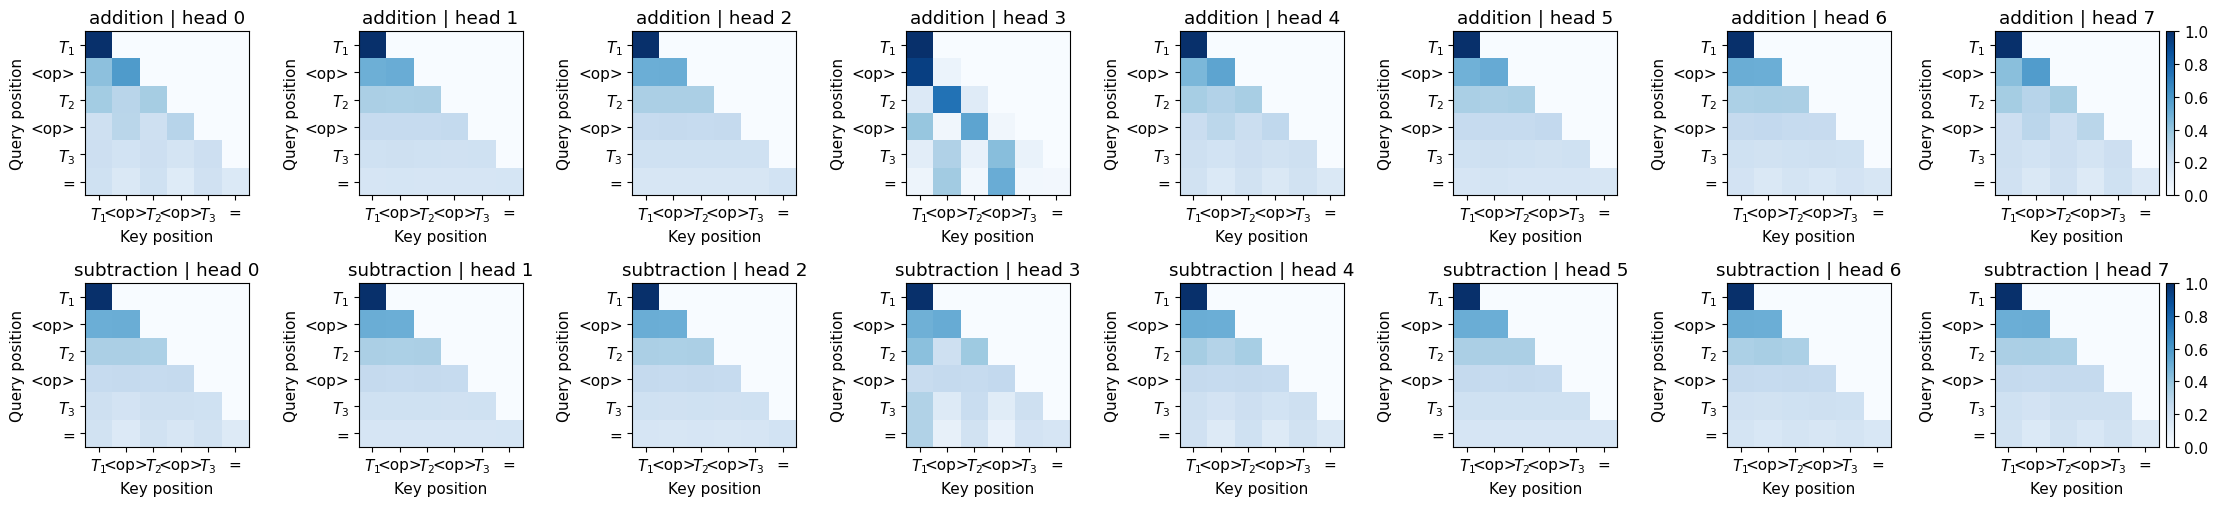

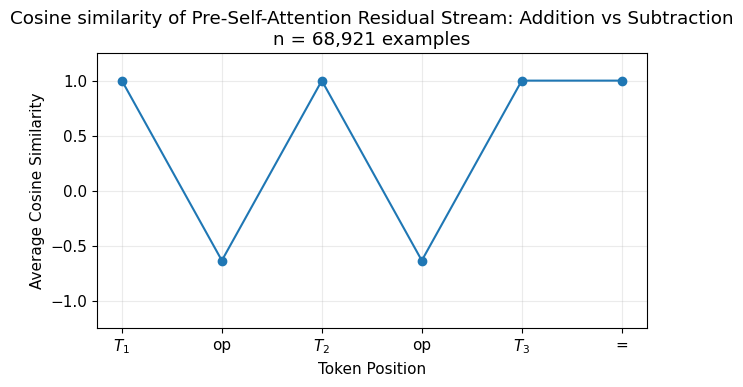

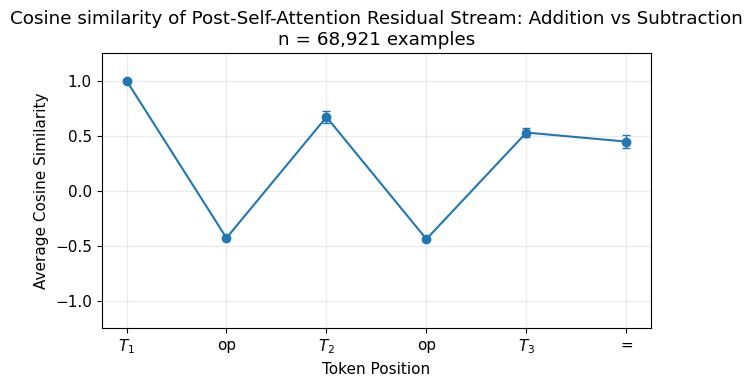

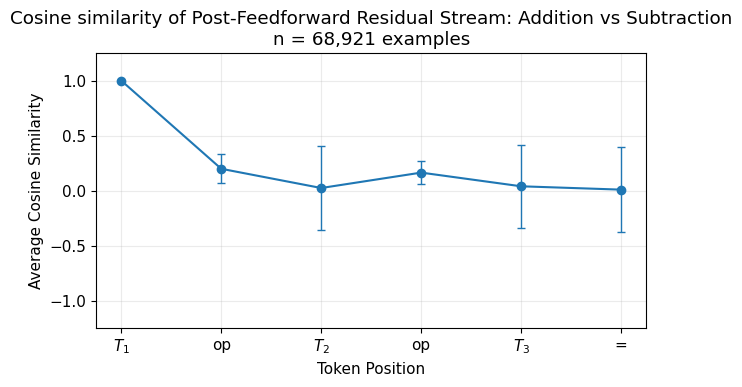

In [60]:
out = get_layer_intermediates_by_operation(model, dataset, 0, max_samples=None)

is_varlen = bool(getattr(dataset, 'is_variable_length', False))
all_res = {}

if is_varlen:
    nterms_list = sorted(dataset.by_nterms.keys())

    for nterms in nterms_list:
        attn_by_op = {}
        for op in out:
            entry = out[op]['by_nterms'].get(nterms)
            if entry is not None:
                attn_by_op[op] = entry['attn_probs']

        if not attn_by_op:
            continue

        sample = next(iter(attn_by_op.values()))
        seq_len = sample.shape[2]
        nt = (seq_len + 1) // 2
        token_labels = []
        for i in range(nt):
            token_labels.append(f'$T_{{{i+1}}}$')
            if i < nt - 1:
                token_labels.append('<op>')
        token_labels.append('=')
        token_labels = token_labels[:seq_len]

        print(f'Attention heatmaps for nterms={nterms}')
        plot_attention_heatmaps(
            attn_by_op,
            token_labels=token_labels,
            reduce='mean',
            vmin=0.0,
            vmax=1.0,
        )

    ops = list(out.keys())
    for nterms in nterms_list:
        for i in range(len(ops)):
            for j in range(i + 1, len(ops)):
                op1, op2 = ops[i], ops[j]
                e1 = out[op1]['by_nterms'].get(nterms)
                e2 = out[op2]['by_nterms'].get(nterms)
                if e1 is None or e2 is None:
                    continue

                for key in e1:
                    if key in ('tokens', 'sa_out') or key not in e2:
                        continue

                    t1 = e1[key]
                    t2 = e2[key]
                    if not isinstance(t1, torch.Tensor) or not isinstance(t2, torch.Tensor):
                        continue
                    if t1.ndim != 3 or t2.ndim != 3:
                        continue
                    if t1.shape[:2] != e1['tokens'].shape[:2] or t2.shape[:2] != e2['tokens'].shape[:2]:
                        continue

                    res = plot_after_sa_cosine_with_overlap(
                        tokens_op1=e1['tokens'],
                        after_sa_op1=t1,
                        name_op1=op1,
                        tokens_op2=e2['tokens'],
                        after_sa_op2=t2,
                        name_op2=op2,
                        title=f"nterms={nterms} | {stage_display_name(key)}: {str(op1).replace('_', ' ').title()} vs {str(op2).replace('_', ' ').title()}",
                        term_positions=getattr(dataset, 'term_positions', None),
                    )
                    all_res[(nterms, op1, op2, key)] = res
else:
    attn_by_op = {}
    for op in out:
        attn_by_op[op] = out[op]['attn_probs']

    if hasattr(dataset, 'term_positions') and dataset.term_positions is not None:
        nterms = len(dataset.term_positions)
    else:
        sample_tokens = next(iter(out.values()))['sa_in']
        seq_len = sample_tokens.shape[1]
        nterms = (seq_len + 1) // 2

    token_labels = []
    for i in range(nterms):
        token_labels.append(f'$T_{{{i+1}}}$')
        if i < nterms - 1:
            token_labels.append('<op>')
    token_labels.append('=')

    plot_attention_heatmaps(
        attn_by_op,
        token_labels=token_labels,
        reduce='mean',
        vmin=0.0,
        vmax=1.0,
    )

    ops = list(out.keys())
    for i in range(len(ops)):
        for j in range(i + 1, len(ops)):
            op1, op2 = ops[i], ops[j]

            tokens1 = out[op1]['tokens']
            tokens2 = out[op2]['tokens']

            for key in out[op1]:
                if key in ('tokens', 'sa_out') or key not in out[op2]:
                    continue

                t1 = out[op1][key]
                t2 = out[op2][key]
                if not isinstance(t1, torch.Tensor) or not isinstance(t2, torch.Tensor):
                    continue
                if t1.ndim != 3 or t2.ndim != 3:
                    continue
                if t1.shape[:2] != tokens1.shape[:2] or t2.shape[:2] != tokens2.shape[:2]:
                    continue

                res = plot_after_sa_cosine_with_overlap(
                    tokens_op1=tokens1,
                    after_sa_op1=t1,
                    name_op1=op1,
                    tokens_op2=tokens2,
                    after_sa_op2=t2,
                    name_op2=op2,
                    title=f"{stage_display_name(key)}: {str(op1).replace('_', ' ').title()} vs {str(op2).replace('_', ' ').title()}",
                    term_positions=getattr(dataset, 'term_positions', None),
                )
                all_res[(op1, op2, key)] = res
